In [1]:
import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.append('../..')

# Verify PyPortfolioOpt installed
try:
    from pypfopt import EfficientFrontier
    print('PyPortfolioOpt OK')
except ImportError:
    print('MISSING: pip install PyPortfolioOpt --break-system-packages')

# Verify cvxpy installed
try:
    import cvxpy
    print('cvxpy OK')
except ImportError:
    print('MISSING: pip install cvxpy --break-system-packages')

# Verify risk module
import importlib
import src.risk.risk_engine as re_mod
import src.risk.portfolio_optimizer as po_mod

importlib.reload(re_mod)
importlib.reload(po_mod)

from src.risk.risk_engine import (
    full_risk_report,
    risk_report_all_tickers,
    load_returns
)

from src.risk.portfolio_optimizer import (
    load_price_matrix,
    optimize_max_sharpe,
    optimize_min_volatility,
    optimize_equal_weight,
    optimize_model_weighted
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../../docs/risk', exist_ok=True)

print('All imports OK')

PyPortfolioOpt OK
cvxpy OK
All imports OK


In [2]:
print('Calculating risk metrics for all tickers...')
print('Using FULL dataset (2015-2025) for historical context')
print()
# Full dataset risk report
risk_df = risk_report_all_tickers()
print('\n' + '='*65)
print('ATLAS RISK REPORT — ALL 10 TICKERS (2015-2025)')
print('='*65)
print(risk_df[[
    'ann_return', 'ann_volatility', 'sharpe_ratio',
    'sortino_ratio', 'max_drawdown', 'var_95', 'cvar_95'
]].to_string())
print('\n--- RANKINGS ---')
print(f'Best Sharpe:      {risk_df["sharpe_ratio"].idxmax()} '
      f'({risk_df["sharpe_ratio"].max():.3f})')
print(f'Worst Sharpe:     {risk_df["sharpe_ratio"].idxmin()} '
      f'({risk_df["sharpe_ratio"].min():.3f})')
print(f'Least Drawdown:   {risk_df["max_drawdown"].idxmax()} '
      f'({risk_df["max_drawdown"].max():.1f}%)')
print(f'Worst Drawdown:   {risk_df["max_drawdown"].idxmin()} '
      f'({risk_df["max_drawdown"].min():.1f}%)')
print(f'Highest Return:   {risk_df["ann_return"].idxmax()} '
      f'({risk_df["ann_return"].max():.1f}%)')

Calculating risk metrics for all tickers...
Using FULL dataset (2015-2025) for historical context

  AAPL: Sharpe=0.815 MaxDD=-38.5%
  MSFT: Sharpe=0.811 MaxDD=-37.1%
  GOOGL: Sharpe=0.696 MaxDD=-44.3%
  AMZN: Sharpe=0.596 MaxDD=-56.1%
  META: Sharpe=0.547 MaxDD=-76.7%
  JPM: Sharpe=0.633 MaxDD=-43.6%
  GS: Sharpe=0.593 MaxDD=-48.8%
  BAC: Sharpe=0.453 MaxDD=-49.0%
  NVDA: Sharpe=1.241 MaxDD=-66.3%
  TSLA: Sharpe=0.790 MaxDD=-73.6%

ATLAS RISK REPORT — ALL 10 TICKERS (2015-2025)
        ann_return  ann_volatility  sharpe_ratio  sortino_ratio  max_drawdown  var_95  cvar_95
ticker                                                                                        
AAPL         28.70           29.08         0.815          1.353        -38.52  -2.768   -4.179
MSFT         26.71           26.78         0.811          1.370        -37.15  -2.630   -3.810
GOOGL        25.10           28.87         0.696          1.189        -44.32  -2.763   -4.208
AMZN         24.60           32.88       

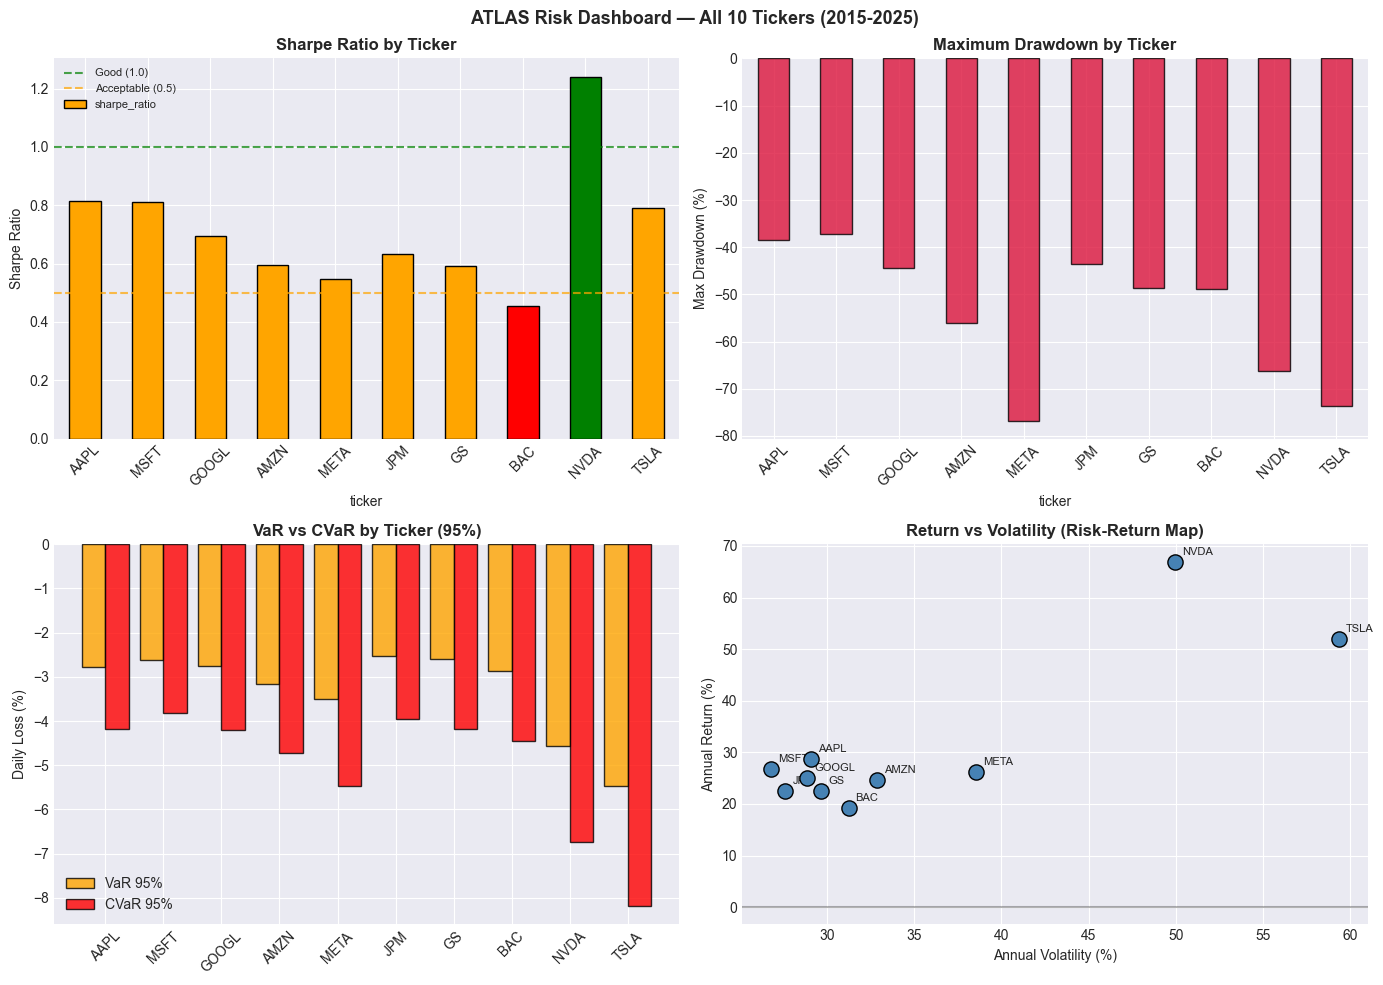

Chart saved: docs/risk/01_risk_dashboard.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: Sharpe Ratio
colors_sharpe = ['green' if v > 1.0 else 'orange' if v > 0.5
                  else 'red' for v in risk_df['sharpe_ratio']]
risk_df['sharpe_ratio'].plot(
    kind='bar', ax=axes[0,0],
    color=colors_sharpe, edgecolor='black'
)
axes[0,0].axhline(1.0, color='green', linestyle='--',
                   alpha=0.7, label='Good (1.0)')
axes[0,0].axhline(0.5, color='orange', linestyle='--',
                   alpha=0.7, label='Acceptable (0.5)')
axes[0,0].set_title('Sharpe Ratio by Ticker', fontweight='bold')
axes[0,0].set_ylabel('Sharpe Ratio')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(fontsize=8)

# Top right: Max Drawdown
risk_df['max_drawdown'].plot(
    kind='bar', ax=axes[0,1],
    color='crimson', edgecolor='black', alpha=0.8
)
axes[0,1].set_title('Maximum Drawdown by Ticker', fontweight='bold')
axes[0,1].set_ylabel('Max Drawdown (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Bottom left: VaR and CVaR
x = range(len(risk_df))
axes[1,0].bar([i-0.2 for i in x], risk_df['var_95'], 
              width=0.4, label='VaR 95%',
              color='orange', edgecolor='black', alpha=0.8)
axes[1,0].bar([i+0.2 for i in x], risk_df['cvar_95'],
              width=0.4, label='CVaR 95%',
              color='red', edgecolor='black', alpha=0.8)
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(risk_df.index, rotation=45)
axes[1,0].set_title('VaR vs CVaR by Ticker (95%)',
                     fontweight='bold')
axes[1,0].set_ylabel('Daily Loss (%)')
axes[1,0].legend()

# Bottom right: Return vs Volatility scatter
axes[1,1].scatter(
    risk_df['ann_volatility'],
    risk_df['ann_return'],
    s=120, color='steelblue', edgecolor='black', zorder=5
)

for ticker in risk_df.index:
    axes[1,1].annotate(
        ticker,
        (risk_df.loc[ticker,'ann_volatility'],
         risk_df.loc[ticker,'ann_return']),
        textcoords='offset points',
        xytext=(5, 5), fontsize=8
    )

axes[1,1].axhline(0, color='black', alpha=0.3)
axes[1,1].set_xlabel('Annual Volatility (%)')
axes[1,1].set_ylabel('Annual Return (%)')
axes[1,1].set_title('Return vs Volatility (Risk-Return Map)',
                     fontweight='bold')

plt.suptitle('ATLAS Risk Dashboard — All 10 Tickers (2015-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/risk/01_risk_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved: docs/risk/01_risk_dashboard.png')

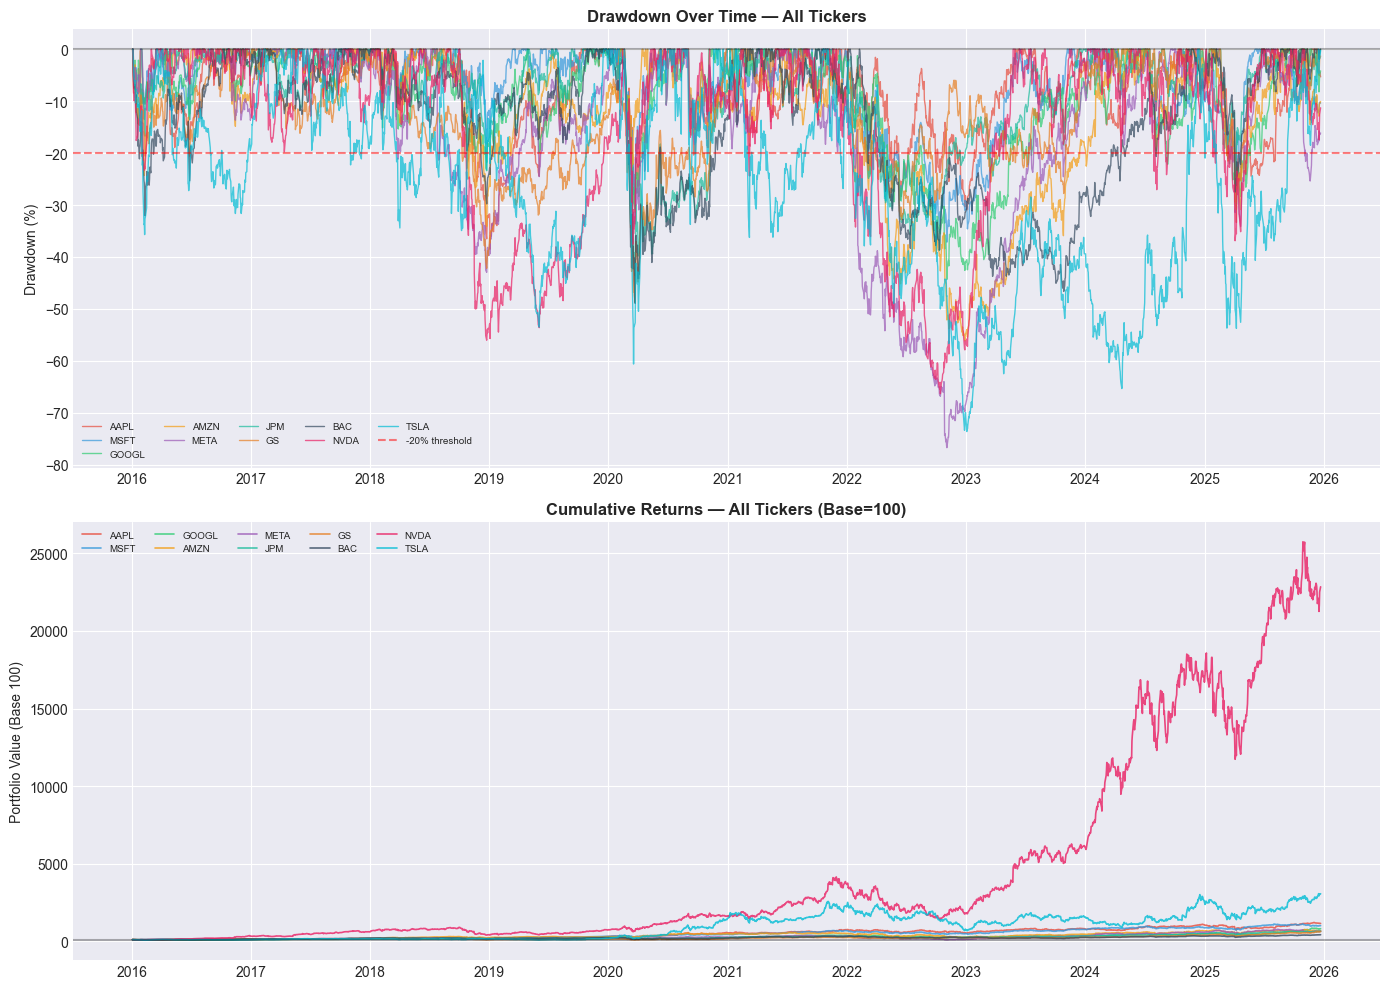

Chart saved: docs/risk/02_drawdown_cumulative.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Drawdown curves for all tickers
colors_list = ['#E74C3C','#3498DB','#2ECC71','#F39C12',
               '#9B59B6','#1ABC9C','#E67E22','#34495E',
               '#E91E63','#00BCD4']

for i, ticker in enumerate(risk_df.index):
    returns  = load_returns(ticker)
    cum      = (1 + returns).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max * 100
    axes[0].plot(drawdown.index, drawdown.values,
                 label=ticker, color=colors_list[i],
                 alpha=0.7, linewidth=1)

axes[0].set_title('Drawdown Over Time — All Tickers', fontweight='bold')
axes[0].set_ylabel('Drawdown (%)')
axes[0].axhline(0, color='black', alpha=0.3)
axes[0].axhline(-20, color='red', linestyle='--',
                 alpha=0.5, label='-20% threshold')
axes[0].legend(fontsize=7, ncol=5)

# Bottom: Cumulative returns for all tickers
for i, ticker in enumerate(risk_df.index):
    returns = load_returns(ticker)
    cum     = (1 + returns).cumprod() * 100
    axes[1].plot(cum.index, cum.values,
                 label=ticker, color=colors_list[i],
                 alpha=0.8, linewidth=1.2)

axes[1].set_title('Cumulative Returns — All Tickers (Base=100)', fontweight='bold')
axes[1].set_ylabel('Portfolio Value (Base 100)')
axes[1].axhline(100, color='black', alpha=0.3)
axes[1].legend(fontsize=7, ncol=5)

plt.tight_layout()
plt.savefig('../../docs/risk/02_drawdown_cumulative.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved: docs/risk/02_drawdown_cumulative.png')

In [5]:
print('Loading price matrix for optimization...')
# Use training period only — no data leakage
prices = load_price_matrix(
    start_date='2015-01-01',
    end_date='2022-12-31'
)

print('\nRunning 3 portfolio optimization strategies...')

# Strategy 1: Maximum Sharpe
try:
    max_sharpe = optimize_max_sharpe(prices)
    print(f'\nMax Sharpe Portfolio:')
    print(f'  Expected Return: {max_sharpe["exp_return"]}%')
    print(f'  Volatility:      {max_sharpe["volatility"]}%')
    print(f'  Sharpe Ratio:    {max_sharpe["sharpe"]}')
    print(f'  Weights:')
    for t, w in sorted(max_sharpe['weights'].items(),
                        key=lambda x: x[1], reverse=True):
        if w > 0.001:
            print(f'    {t}: {w*100:.1f}%')
except Exception as e:
    print(f'Max Sharpe failed: {e}')
    max_sharpe = optimize_equal_weight(list(prices.columns))

# Strategy 2: Minimum Volatility
try:
    min_vol = optimize_min_volatility(prices)
    print(f'\nMin Volatility Portfolio:')
    print(f'  Expected Return: {min_vol["exp_return"]}%')
    print(f'  Volatility:      {min_vol["volatility"]}%')
    print(f'  Sharpe Ratio:    {min_vol["sharpe"]}')
    print(f'  Weights:')
    for t, w in sorted(min_vol['weights'].items(),
                        key=lambda x: x[1], reverse=True):
        if w > 0.001:
            print(f'    {t}: {w*100:.1f}%')
except Exception as e:
    print(f'Min Vol failed: {e}')
    min_vol = optimize_equal_weight(list(prices.columns))

# Strategy 3: Equal Weight baseline
equal_w = optimize_equal_weight(list(prices.columns))
print(f'\nEqual Weight: 10% each ticker (baseline)')

Loading price matrix for optimization...
Price matrix: (1762, 10) (2016-01-04 to 2022-12-30)

Running 3 portfolio optimization strategies...

Max Sharpe Portfolio:
  Expected Return: 34.69%
  Volatility:      31.7%
  Sharpe Ratio:    0.936
  Weights:
    AAPL: 30.0%
    MSFT: 30.0%
    NVDA: 30.0%
    TSLA: 9.0%
    JPM: 1.0%

Min Volatility Portfolio:
  Expected Return: 17.06%
  Volatility:      23.76%
  Sharpe Ratio:    0.508
  Weights:
    JPM: 30.0%
    GOOGL: 22.8%
    MSFT: 14.2%
    AMZN: 12.9%
    AAPL: 12.4%
    GS: 7.6%

Equal Weight: 10% each ticker (baseline)


In [6]:
import joblib
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from src.models.data_loader import load_splits

# Get model prediction probability for each ticker
# This is what makes ATLAS portfolio different from
# standard Mean-Variance — we incorporate ML signals
print('Getting ATLAS model signals for all tickers...')
model_path = '../../experiments/models/xgboost_AAPL.pkl'
model = joblib.load(model_path)
model_signals = {}

for ticker in list(prices.columns):
    try:
        X_train, y_train, X_val, y_val, X_test, y_test = (
            load_splits(ticker)
        )
        
        # Use most recent test data for signal
        latest = X_test.iloc[[-1]]
        
        # Keep only features the model was trained on
        model_features = model.get_booster().feature_names
        available = [f for f in model_features if f in latest.columns]
        
        if len(available) == len(model_features):
            prob_up = model.predict_proba(latest[model_features])[0][1]
        else:
            prob_up = 0.5  # neutral if features missing
            
        model_signals[ticker] = round(prob_up, 3)
        signal = 'BULL' if prob_up > 0.5 else 'BEAR'
        print(f'  {ticker}: {signal} ({prob_up:.1%})')
        
    except Exception as e:
        model_signals[ticker] = 0.5
        print(f'  {ticker}: neutral (error: {str(e)[:40]})')

# Build model-weighted portfolio
try:
    atlas_portfolio = optimize_model_weighted(
        prices, model_signals
    )
    print(f'\nATLAS Model-Weighted Portfolio:')
    print(f'  Expected Return: {atlas_portfolio["exp_return"]}%')
    print(f'  Volatility:      {atlas_portfolio["volatility"]}%')
    print(f'  Sharpe Ratio:    {atlas_portfolio["sharpe"]}')
    print(f'  Weights:')
    for t, w in sorted(atlas_portfolio['weights'].items(),
                        key=lambda x: x[1], reverse=True):
        if w > 0.001:
            print(f'    {t}: {w*100:.1f}%')
except Exception as e:
    print(f'Model portfolio failed: {e}')
    atlas_portfolio = equal_w

Getting ATLAS model signals for all tickers...
AAPL — Train:1762 Val:124 Test:622
  AAPL: BEAR (15.8%)
MSFT — Train:1762 Val:124 Test:622
  MSFT: BEAR (46.6%)
GOOGL — Train:1762 Val:124 Test:622
  GOOGL: BEAR (2.4%)
AMZN — Train:1762 Val:124 Test:622
  AMZN: BEAR (4.3%)
META — Train:1762 Val:124 Test:622
  META: BEAR (2.5%)
JPM — Train:1762 Val:124 Test:622
  JPM: BEAR (1.4%)
GS — Train:1762 Val:124 Test:622
  GS: BEAR (7.8%)
BAC — Train:1762 Val:124 Test:622
  BAC: BEAR (0.8%)
NVDA — Train:1762 Val:124 Test:622
  NVDA: BEAR (50.0%)
TSLA — Train:1762 Val:124 Test:622
  TSLA: BEAR (4.2%)

ATLAS Model-Weighted Portfolio:
  Expected Return: 32.36%
  Volatility:      31.1%
  Sharpe Ratio:    0.88
  Weights:
    AAPL: 30.0%
    MSFT: 30.0%
    NVDA: 30.0%
    TSLA: 6.2%
    JPM: 3.8%


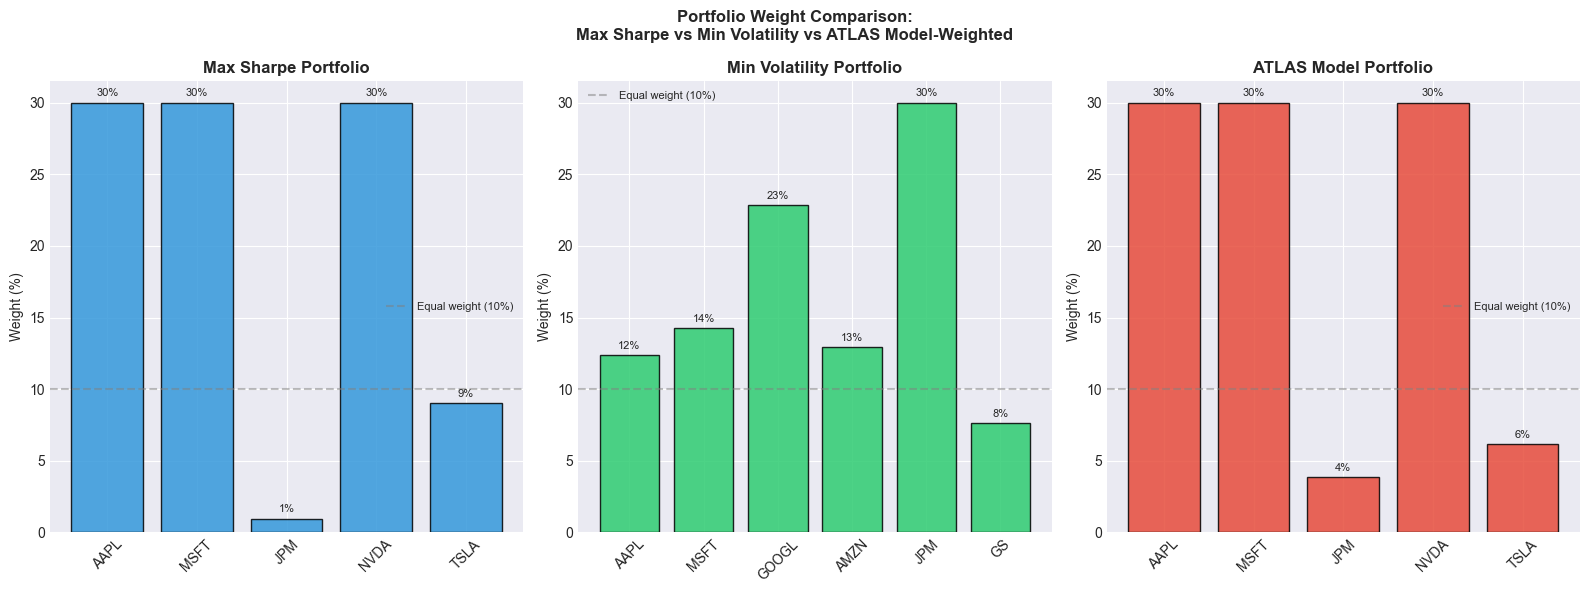

Chart saved: docs/risk/03_portfolio_weights.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

strategies = [
    ('Max Sharpe',     max_sharpe['weights'],    '#3498DB'),
    ('Min Volatility', min_vol['weights'],       '#2ECC71'),
    ('ATLAS Model',    atlas_portfolio['weights'],'#E74C3C'),
]

for ax, (name, weights, color) in zip(axes, strategies):
    tickers_w = [t for t, w in weights.items() if w > 0.001]
    values_w  = [weights[t] * 100 for t in tickers_w]
    
    bars = ax.bar(tickers_w, values_w,
                  color=color, edgecolor='black', alpha=0.85)
    
    ax.axhline(10, color='grey', linestyle='--',
               alpha=0.5, label='Equal weight (10%)')
    
    ax.set_title(f'{name} Portfolio', fontweight='bold')
    ax.set_ylabel('Weight (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
    
    for bar, val in zip(bars, values_w):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.0f}%',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Portfolio Weight Comparison:\n'
             'Max Sharpe vs Min Volatility vs ATLAS Model-Weighted',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../../docs/risk/03_portfolio_weights.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved: docs/risk/03_portfolio_weights.png')

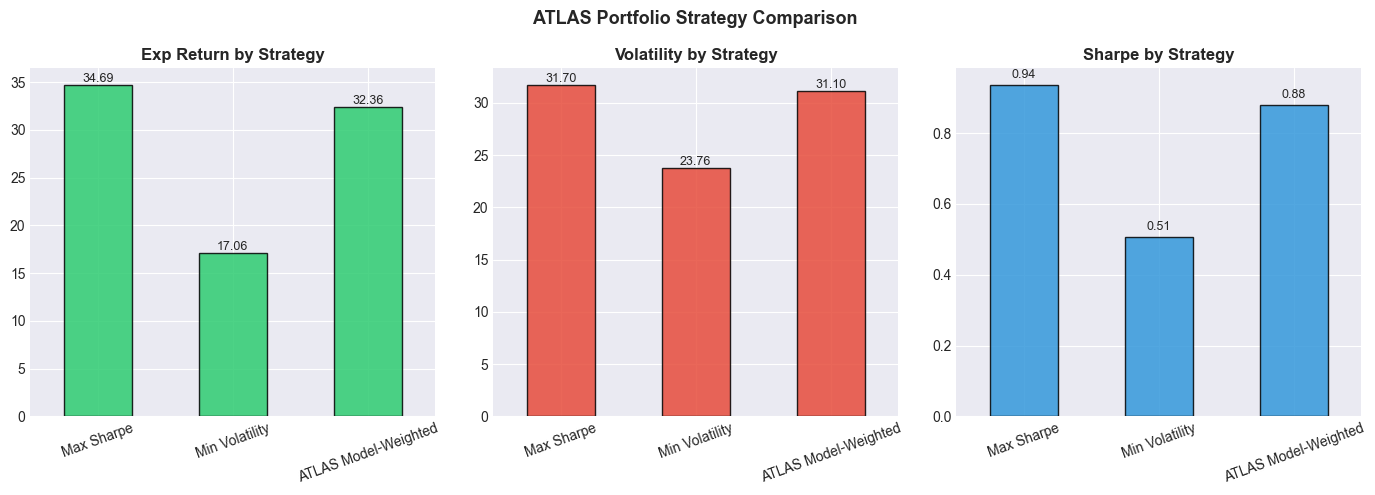


PORTFOLIO STRATEGY SUMMARY
                      Exp Return  Volatility  Sharpe
Strategy                                            
Max Sharpe                 34.69       31.70   0.936
Min Volatility             17.06       23.76   0.508
ATLAS Model-Weighted       32.36       31.10   0.880

Chart saved: docs/risk/04_strategy_comparison.png


In [8]:
# Compare all strategies on key metrics
summary_data = []
for strat in [max_sharpe, min_vol, atlas_portfolio]:
    if strat['exp_return'] is not None:
        summary_data.append({
            'Strategy':    strat['strategy'],
            'Exp Return':  strat['exp_return'],
            'Volatility':  strat['volatility'],
            'Sharpe':      strat['sharpe'],
        })

summary_df = pd.DataFrame(summary_data).set_index('Strategy')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['Exp Return', 'Volatility', 'Sharpe']
bar_colors = ['#2ECC71', '#E74C3C', '#3498DB']

for ax, metric, color in zip(axes, metrics, bar_colors):
    summary_df[metric].plot(
        kind='bar', ax=ax,
        color=color, edgecolor='black', alpha=0.85
    )
    ax.set_title(f'{metric} by Strategy',
                  fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_xlabel('')
    
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('ATLAS Portfolio Strategy Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/risk/04_strategy_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('PORTFOLIO STRATEGY SUMMARY')
print('='*50)
print(summary_df.to_string())
print('\nChart saved: docs/risk/04_strategy_comparison.png')